In [ ]:
EXPERIMENTAL_ID="recommend_home_202511"
START_DATE="2025-12-05"

In [ ]:
from odps_client import get_odps_sql_result_as_df
from datetime import datetime, timedelta


In [ ]:
from sls_client import get_sls_data_by_query
from datetime import datetime, timedelta
import pandas as pd

# 设置pandas显示选项以展示更多内容
pd.set_option("display.max_rows", 100)  # 显示最多100行
pd.set_option("display.max_columns", None)  # 显示所有列
pd.set_option("display.width", 1000)  # 设置显示宽度
pd.set_option("display.max_colwidth", 100)  # 设置列最大宽度

import sqlite3


def get_user_variant_of_date_from_sls(
    day: datetime, check_if_local_exist: bool = True
) -> pd.DataFrame:
    """
    从SLS(Simple Log Service)获取指定日期的用户变体数据。

    Args:
        day (datetime): 要获取数据的日期。
        check_if_local_exist (bool): 是否检查本地数据库中是否已存在数据，默认为True。

    Returns:
        pd.DataFrame: 包含用户变体数据的DataFrame。
    """
    # 构建数据库文件名和表名
    db_file_name = f"./data/recommend_ab_user_variant.db"
    table_name = f"recommend_ab_user_variant_{day.strftime('%Y%m%d')}"
    # 连接到SQLite数据库
    conn = sqlite3.connect(db_file_name)

    # 如果设置为检查本地数据
    if check_if_local_exist:
        try:
            # 尝试从数据库中读取数据
            query = f"SELECT * FROM {table_name}"
            df = pd.read_sql_query(query, conn)
            # 关闭数据库连接
            conn.close()
            # 返回读取的数据
            return df
        except pd.io.sql.DatabaseError:
            # 如果表不存在，则忽略错误
            pass

    # 构建SLS查询语句
    query = f"""
type:a and ap:/recommend/ and pageName:/home and not ap:/recommend/tab
| SELECT 
    regexp_replace(ap, '\d+','{{digit}}') as api,
    pageName as page_name,
    regexp_extract(experiment_item, '"experimentId":"([^"]+)"', 1) as experiment_id,
    type,
    uid,
    date_format(__time__, '%Y%m%d') as ds,
    count(1) as search_times,
    array_join(array_sort(array_agg(distinct regexp_extract(experiment_item, '"variantId":"([^"]+)"', 1))),',') as variant_list
FROM log, 
UNNEST(regexp_extract_all(json_extract_scalar(ai, '$.qh.xm-ab-exp'), '\{{[^}}]+\}}')) as t(experiment_item)
WHERE experiment_item LIKE '%"experimentId":"{EXPERIMENTAL_ID}"%'
GROUP BY 1,2,3,4,5,6
LIMIT 1000000
"""
    # 设置查询的起始时间和结束时间
    print(query)
    from_time = day.replace(hour=0, minute=0, second=0, microsecond=0)
    to_time = day.replace(hour=23, minute=59, second=59, microsecond=999999)
    # 从SLS获取数据
    _df = get_sls_data_by_query(
        query=query,
        project="xianmu-front-end-log",  # 指定SLS项目
        logstore="xm-mall",  # 指定SLS日志库
        from_time=from_time,  # 指定查询起始时间
        to_time=to_time,  # 指定查询结束时间
    )

    # 将search_times列中的缺失值填充为1，并转换为整数类型
    _df["search_times"] = _df["search_times"].fillna(1).astype(int)
    # 将variant_list列中的缺失值填充为"none"
    _df["variant_list"] = _df["variant_list"].fillna("none")

    # 如果DataFrame不为空
    if not _df.empty:
        # 删除不需要的列
        _df.drop(columns=["__source__", "__time__"], inplace=True)
        # 将数据写入SQLite数据库，如果表已存在则替换
        _df.to_sql(table_name, conn, if_exists="replace", index=False)
    # 关闭数据库连接
    conn.close()
    # 返回数据
    return _df


# 创建一个空的DataFrame来存储所有日期的用户变体数据
all_user_variant_df = pd.DataFrame()
# 设置起始日期和结束日期
start_date = datetime.strptime(START_DATE, "%Y-%m-%d")
end_date = datetime.now()
# 从起始日期开始循环，直到结束日期
current_date = start_date
while current_date <= end_date:
    # 检查是否是今天
    is_today = current_date.strftime("%Y%m%d") == end_date.strftime("%Y%m%d")
    # 如果是今天,则跳过，因为今天的数据可能不完整
    if is_today:
        print(f"今天的数据还未完整，跳过:{current_date}")
        break
    # 获取当前日期的用户变体数据
    df = get_user_variant_of_date_from_sls(current_date, check_if_local_exist=True)
    # 将当前日期的数据添加到总的DataFrame中
    all_user_variant_df = pd.concat([all_user_variant_df, df], ignore_index=True)
    # 日期增加一天
    current_date += timedelta(days=1)

# 显示前10行数据
all_user_variant_df.head(10)

In [ ]:
import pandasql
stats=pandasql.sqldf("""select ds,variant_list,count(distinct uid) unique_user 
                     from all_user_variant_df group by ds,variant_list order by ds desc,variant_list""")

display(stats)

In [ ]:
# idx:4,name:徐州奶油草莓 净重3-3.2斤/一级/单果10g+/板装,pid:goods,sku:5442468008,salePrice:69.5,pdid:702,stock:10000,ext:cross;idx:5,name:徐州奶油草莓 280G*1盒/一级/4*6/ ,pid:goods,sku:5442468073,salePrice:16.5,pdid:702,stock:10000,ext:cross;idx:6,name:徐州奶油草莓 净重2.8-3斤/一级/单果10g+/ 10盒,pid:goods,sku:5442468518,salePrice:74.5,pdid:702,stock:10000,ext:cross

view_query = """
type:cl or type:view | select ds,
    pageName as "页面名称",uid,sku_viewed_or_clicked,
    count(distinct case when type='view' and position_id='goods' then (uid,sku_viewed_or_clicked,__time__,idx) end) as "SKU曝光次数",
    count(distinct case when type='cl' and position_id in ('goods','唤起购买') then (uid,sku_viewed_or_clicked,__time__,idx) end) as "SKU点击次数",
    round(1.00*count(distinct case when type='cl' and position_id in ('goods','唤起购买') then (uid,sku_viewed_or_clicked,__time__,idx) end)/count(distinct case when type='view' and position_id='goods' then (uid,sku_viewed_or_clicked,__time__,idx) end),4) as "SKU点击率",
    count(distinct case when type='cl' and position_id in ('goods','唤起购买') and idx <= 3 then (uid,sku_viewed_or_clicked,__time__,idx) end) as "前4位SKU点击次数",
    count(distinct case when type='cl' and position_id='唤起购买' then (uid,sku_viewed_or_clicked,__time__,idx) end) as "唤起加购弹窗点击次数",
    count(distinct case when type='cl' and position_id='加购弹窗' and position_name='加入购物车' then (uid,sku_viewed_or_clicked,__time__,idx) end) as "加入购物车次数",
    count(distinct case when type='cl' and position_id='加购弹窗' and position_name='立即购买' then (uid,sku_viewed_or_clicked,__time__,idx) end) as "立即购买次数",
    round(avg(case when type='cl' then idx end),2) as "平均点击位置",
    max(case when type='cl' then idx end) as "最大点击位置",
    min(case when type='cl' then idx end) as "最小点击位置",
    round(avg(case when type='view' and position_id='goods' then idx end),2) as "平均曝光位置",
    max(case when type='view' and position_id='goods' then idx end) as "最大曝光位置",
    min(case when type='view' and position_id='goods' then idx end) as "最小曝光位置",
    count(0) as "总事件数" 
from (
    select pageName,
        type,
        case when COALESCE(regexp_extract(bid, 'pid:([^,]+)', 1),pid) in ('goods','唤起购买') and type='cl' 
            then COALESCE(regexp_extract(bid, 'pid:([^,]+)', 1),pid) 
            else COALESCE(regexp_extract(bid, 'name:([^,]+)', 1),name) 
        end as position_name,
        COALESCE(regexp_extract(bid, 'pid:([^,]+)', 1),pid) as position_id,
        uid,__time__,
        cast(COALESCE(regexp_extract(bid, 'idx:([0-9]+)', 1),idx) as bigint) as idx,
        COALESCE(regexp_extract(bid, 'sku:([0-9a-zA-Z]{1,20})', 1),sku) as sku_viewed_or_clicked,
        date_format(__time__,'%Y%m%d') ds
    from log 
    where pageName like '/home%'
        and COALESCE(regexp_extract(bid, 'sku:([0-9a-zA-Z]{1,20})', 1),sku) is not null 
    limit 100000000
)
group by 1,2,3,4
having length(uid)>0
order by 5 desc
"""


def get_user_sku_view_of_date_from_sls(
    day: datetime, check_if_local_exist: bool = True
) -> pd.DataFrame:
    db_file_name = f"./data/recommend_ab_user_sku_view.db"
    table_name = f"user_sku_view_{day.strftime('%Y%m%d')}"
    conn = sqlite3.connect(db_file_name)
    cursor = conn.cursor()

    if check_if_local_exist:
        try:
            query = f"SELECT * FROM {table_name}"
            df = pd.read_sql_query(query, conn)
            conn.close()
            return df
        except pd.io.sql.DatabaseError:
            pass

    from_time = day.replace(hour=0, minute=0, second=0, microsecond=0)
    to_time = day.replace(hour=23, minute=59, second=59, microsecond=999999)
    _df = get_sls_data_by_query(
        query=view_query,
        project="xianmu-front-end-log",
        logstore="xm-mall",
        from_time=from_time,
        to_time=to_time,
    )

    if not _df.empty:
        _df.drop(columns=["__source__", "__time__"], inplace=True)
        _df.to_sql(table_name, conn, if_exists="replace", index=False)
    conn.close()
    return _df


all_user_sku_view_df = pd.DataFrame()
current_date = start_date
while current_date <= end_date:
    is_today = current_date.strftime("%Y%m%d") == end_date.strftime("%Y%m%d")
    if is_today:
        print(f"今天的数据还未完整，跳过:{current_date}")
        break
    df = get_user_sku_view_of_date_from_sls(current_date, check_if_local_exist=True)
    all_user_sku_view_df = pd.concat([all_user_sku_view_df, df], ignore_index=True)
    current_date += timedelta(days=1)

In [ ]:
all_user_sku_view_df.groupby("ds").size().reset_index(name="count").sort_values(
    "ds", ascending=False
).head(10)

user_click_with_variant_statistics_df = all_user_sku_view_df.merge(
    all_user_variant_df[["uid", "ds", "variant_list"]],
    on=["uid", "ds"],
    how="left",
)

print("non variant count:", user_click_with_variant_statistics_df[
    user_click_with_variant_statistics_df["variant_list"].isna()
].shape[0])

print("total count:", len(user_click_with_variant_statistics_df))

print("variant count:", len(user_click_with_variant_statistics_df[
    user_click_with_variant_statistics_df["variant_list"].notna()
]))

variant_ratio = len(user_click_with_variant_statistics_df[
    user_click_with_variant_statistics_df["variant_list"].notna()
]) / len(user_click_with_variant_statistics_df)
print("variant ratio:", f"{variant_ratio:.4%}")

user_click_with_variant_statistics_df.head(5)

print("drop non variant users...")
user_click_with_variant_statistics_df = user_click_with_variant_statistics_df[
    user_click_with_variant_statistics_df["variant_list"].notna()
]

In [ ]:

user_click_with_variant_statistics_df['SKU点击次数'] = user_click_with_variant_statistics_df['SKU点击次数'].astype(int)

core_metrics = []
for metric in ['SKU点击次数', 'SKU曝光次数', '加入购物车次数', '立即购买次数', '平均曝光位置']:
    if metric != '平均曝光位置':
        user_click_with_variant_statistics_df[metric] = user_click_with_variant_statistics_df[metric].astype(int)
    else:
        user_click_with_variant_statistics_df[metric] = user_click_with_variant_statistics_df[metric].apply(lambda x: x if x is not None and x != 'null' and x != '' and pd.notna(x) else 0.0)
        user_click_with_variant_statistics_df[metric].fillna(0.0, inplace=True)
        user_click_with_variant_statistics_df[metric] = user_click_with_variant_statistics_df[metric].astype(float)
    for variant_list, group_df in user_click_with_variant_statistics_df.groupby('variant_list'):
        mean = group_df[metric].mean()
        max_val = group_df[metric].max()
        std = group_df[metric].std()
        total_cnt = group_df[metric].sum()
        conv_user_count = group_df[group_df[metric] > 0]['uid'].nunique()
        total_user_count = group_df['uid'].nunique()
        user_conv_rate = round(1.00 * conv_user_count / total_user_count, 4) if total_user_count > 0 else 0.0
        p_75 = group_df[metric].quantile(0.75)
        p_95 = group_df[metric].quantile(0.95)
        p_99 = group_df[metric].quantile(0.99)
        p_999 = group_df[metric].quantile(0.999)

        core_metrics.append({
            "metric": metric,
            "variant_list": variant_list,
            "mean": float(mean),
            "max": float(max_val),
            "std": float(std),
            "total_count": int(total_cnt),
            "conv_user_count": int(conv_user_count),
            "total_user_count": int(total_user_count),
            "user_conv_rate": float(user_conv_rate),
            "p75": float(p_75),
            "p95": float(p_95),
            "p99": float(p_99),
            "p999": float(p_999)
        })

core_metrics_df = pd.DataFrame(core_metrics)
core_metrics_df = core_metrics_df.sort_values(by=["metric", "variant_list"])
core_metrics_df


In [ ]:
print(user_click_with_variant_statistics_df.columns)
print(user_click_with_variant_statistics_df.head(5).to_json(force_ascii=False))

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.font_manager import FontProperties
import platform

def setup_chinese_font():
    """
    设置matplotlib中文字体（macOS优化版）
    """
    system = platform.system()
    
    if system == 'Darwin':  # macOS
        # macOS常见中文字体列表（按优先级排序）
        mac_fonts = [
            'PingFang SC',      # 苹方-简（macOS默认中文字体）
            'Heiti SC',         # 黑体-简
            'STHeiti',          # 华文黑体
            'Arial Unicode MS', # Arial Unicode MS
            'Songti SC',        # 宋体-简
            'STSong',           # 华文宋体
        ]
        
        # 尝试设置字体
        for font in mac_fonts:
            try:
                plt.rcParams['font.sans-serif'] = [font] + plt.rcParams['font.sans-serif']
                print(f"✓ 成功设置中文字体: {font}")
                break
            except:
                continue
    
    elif system == 'Windows':
        plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'SimSun']
        print("✓ 成功设置中文字体: Windows")
    
    elif system == 'Linux':
        plt.rcParams['font.sans-serif'] = ['WenQuanYi Micro Hei', 'Droid Sans Fallback', 'DejaVu Sans']
        print("✓ 成功设置中文字体: Linux")
    
    # 解决负号显示问题
    plt.rcParams['axes.unicode_minus'] = False
    
    # 验证字体设置
    test_fig, test_ax = plt.subplots(figsize=(6, 2))
    test_ax.text(0.5, 0.5, '中文测试: 实验组对比分析', 
                 fontsize=16, ha='center', va='center')
    test_ax.set_xlim(0, 1)
    test_ax.set_ylim(0, 1)
    test_ax.axis('off')
    plt.tight_layout()
    plt.show()
    plt.close()
    
    print("✓ 中文字体配置完成")

# 执行字体设置
setup_chinese_font()

In [ ]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import platform
import warnings
warnings.filterwarnings('ignore')

# 设置中文字体
if platform.system() == 'Darwin':  # macOS
    plt.rcParams['font.sans-serif'] = ['PingFang SC', 'Arial Unicode MS', 'STHeiti']
elif platform.system() == 'Windows':
    plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei']
else:
    plt.rcParams['font.sans-serif'] = ['WenQuanYi Micro Hei', 'DejaVu Sans']

plt.rcParams['axes.unicode_minus'] = False

print(f"✓ 字体已配置: {plt.rcParams['font.sans-serif'][0]}")


class ExperimentAnalyzer:
    """实验组对比分析器（修复版 - 动态列检测）"""
    
    def __init__(self, df, group_col='variant_list'):
        """
        初始化分析器
        """
        self.df = df.copy()
        self.group_col = group_col
        
        print("="*70)
        print("数据清理与预处理")
        print("="*70)
        
        # 1. 清理分组列
        print(f"\n原始数据总样本量: {len(self.df)}")
        print(f"分组列缺失值数量: {self.df[group_col].isna().sum()}")
        
        self.df = self.df[self.df[group_col].notna()].copy()
        self.df[group_col] = self.df[group_col].astype(str)
        
        # 2. 动态检测可用列（关键修复）
        print("\n检测可用数据列:")
        available_cols = self.df.columns.tolist()
        print(f"所有列: {available_cols}")
        
        # 列名映射：期望列名 -> 实际列名
        self.col_mapping = {
            # 核心指标（直接映射）
            'SKU点击率': 'SKU点击率',
            'SKU曝光次数': 'SKU曝光次数',
            'SKU点击次数': 'SKU点击次数',
            '加入购物车次数': '加入购物车次数',
            '立即购买次数': '立即购买次数',
            '总事件数': '总事件数',
            
            # 位置指标（映射到实际存在的列）
            '平均点击位置': '平均点击位置',
            '最大点击位置': '最大点击位置',
            '最小点击位置': '最小点击位置',
            '平均曝光位置': '平均曝光位置',
            '最大曝光位置': '最大曝光位置',
            '最小曝光位置': '最小曝光位置',
            
            # 特殊映射：不存在的列用近似替代
            '被点击SKU数': '前4位SKU点击次数',  # 用前4位点击次数近似
            '被查看SKU数': 'SKU曝光次数',         # 用曝光次数近似
            '前4位SKU点击次数': '前4位SKU点击次数',
            '唤起加购弹窗点击次数': '唤起加购弹窗点击次数',
        }
        
        # 筛选实际存在的列
        self.available_cols = {}
        for expected_col, actual_col in self.col_mapping.items():
            if actual_col in self.df.columns:
                self.available_cols[expected_col] = actual_col
                print(f"  ✓ {expected_col} -> {actual_col}")
            else:
                print(f"  ✗ {expected_col} -> {actual_col} (不存在)")
        
        # 3. 数据类型转换
        print("\n数据类型转换:")
        for expected_col, actual_col in self.available_cols.items():
            try:
                self.df[actual_col] = pd.to_numeric(self.df[actual_col], errors='coerce')
                print(f"  ✓ 转换 {actual_col}: {self.df[actual_col].dtype}")
            except Exception as e:
                print(f"  ✗ 转换 {actual_col} 失败: {e}")
        
        # 4. 清理无效数据（inf和NaN）
        print("\n清理无效数据...")
        before_clean = len(self.df)
        
        # 替换 inf 为 NaN
        numeric_cols = list(set(self.available_cols.values()))  # 去重
        self.df[numeric_cols] = self.df[numeric_cols].replace([np.inf, -np.inf], np.nan)
        
        # 统计每列的无效值
        print("\n各列无效值统计:")
        for actual_col in numeric_cols:
            invalid_count = self.df[actual_col].isna().sum()
            if invalid_count > 0:
                print(f"  {actual_col}: {invalid_count} ({invalid_count/len(self.df)*100:.1f}%)")
        
        # 5. 计算衍生指标（修复版 - 使用实际列名）
        self._calculate_derived_metrics()
        
        # 6. 获取实验组信息
        self.groups = sorted(self.df[group_col].unique())
        
        print(f"\n清理后样本量: {len(self.df)}")
        print(f"\n实验组: {self.groups}")
        print(f"\n各组样本量分布:")
        group_counts = self.df[group_col].value_counts().sort_index()
        for group, count in group_counts.items():
            print(f"  {group}: {count} ({count/len(self.df)*100:.1f}%)")
        print()
    
    def _calculate_derived_metrics(self):
        """计算衍生指标（修复版 - 使用映射列名）"""
        
        # 检查必需的基础列是否存在
        base_cols_needed = {
            '唤起加购弹窗点击次数': '唤起加购弹窗点击次数',
            '加入购物车次数': '加入购物车次数', 
            '立即购买次数': '立即购买次数',
            '前4位SKU点击次数': '前4位SKU点击次数',
            'SKU曝光次数': 'SKU曝光次数'
        }
        
        # 只计算可用的衍生指标
        # 1. 加购转化率
        if ('唤起加购弹窗点击次数' in self.available_cols and 
            '加入购物车次数' in self.available_cols):
            
            click_col = self.available_cols['唤起加购弹窗点击次数']
            cart_col = self.available_cols['加入购物车次数']
            
            self.df['加购转化率'] = np.where(
                (self.df[click_col] > 0) & (self.df[click_col].notna()),
                self.df[cart_col] / self.df[click_col],
                np.nan
            )
            print("  ✓ 计算加购转化率")
        else:
            self.df['加购转化率'] = np.nan
            print("  ✗ 跳过加购转化率计算（缺少必需列）")
        
        # 2. 购买转化率
        if ('唤起加购弹窗点击次数' in self.available_cols and 
            '立即购买次数' in self.available_cols):
            
            click_col = self.available_cols['唤起加购弹窗点击次数']
            purchase_col = self.available_cols['立即购买次数']
            
            self.df['购买转化率'] = np.where(
                (self.df[click_col] > 0) & (self.df[click_col].notna()),
                self.df[purchase_col] / self.df[click_col],
                np.nan
            )
            print("  ✓ 计算购买转化率")
        else:
            self.df['购买转化率'] = np.nan
            print("  ✗ 跳过购买转化率计算（缺少必需列）")
        
        # 3. 点击集中度
        if ('被查看SKU数' in self.available_cols and '被点击SKU数' in self.available_cols):
            view_col = self.available_cols['被查看SKU数']
            click_col = self.available_cols['被点击SKU数']
            
            self.df['点击集中度'] = np.where(
                (self.df[view_col] > 0) & (self.df[view_col].notna()),
                self.df[click_col] / self.df[view_col],
                np.nan
            )
            print("  ✓ 计算点击集中度")
        else:
            self.df['点击集中度'] = np.nan
            print("  ✗ 跳过点击集中度计算（缺少必需列）")
        
        # 4. 浏览深度
        if ('SKU曝光次数' in self.available_cols and '被查看SKU数' in self.available_cols):
            exposure_col = self.available_cols['SKU曝光次数']
            view_col = self.available_cols['被查看SKU数']
            
            self.df['浏览深度'] = np.where(
                (self.df[exposure_col] > 0) & (self.df[exposure_col].notna()),
                self.df[view_col] / self.df[exposure_col],
                np.nan
            )
            print("  ✓ 计算浏览深度")
        else:
            self.df['浏览深度'] = np.nan
            print("  ✗ 跳过浏览深度计算（缺少必需列）")
        
        # 清理衍生指标中的异常值
        derived_cols = ['加购转化率', '购买转化率', '点击集中度', '浏览深度']
        for col in derived_cols:
            if col in self.df.columns:
                self.df.loc[self.df[col] > 1, col] = np.nan
                self.df.loc[self.df[col] < 0, col] = np.nan
    
    def descriptive_stats(self):
        """描述性统计分析（修复版 - 动态列检测）"""
        print("=" * 80)
        print("一、描述性统计分析")
        print("=" * 80)
        
        # 使用可用的核心指标
        metrics = [
            'SKU点击率', 'SKU点击次数', '加入购物车次数', '立即购买次数',
            '平均点击位置', '平均曝光位置', '总事件数',
            '加购转化率', '点击集中度', '浏览深度'  # 衍生指标
        ]
        
        stats_list = []
        for metric in metrics:
            if metric not in self.df.columns:
                print(f"\n⚠ 指标 {metric} 不存在，跳过")
                continue
            
            # 过滤有效数据
            valid_data = self.df[self.df[metric].notna()]
            
            if len(valid_data) == 0:
                print(f"\n⚠ 指标 {metric} 无有效数据，跳过")
                continue
            
            group_stats = valid_data.groupby(self.group_col)[metric].agg([
                ('样本量', 'count'),
                ('均值', 'mean'),
                ('中位数', 'median'),
                ('标准差', 'std'),
                ('最小值', 'min'),
                ('最大值', 'max'),
                ('标准误', lambda x: x.sem() if len(x) > 1 else np.nan),
                ('95%CI下限', lambda x: x.mean() - 1.96 * x.sem() if len(x) > 1 else np.nan),
                ('95%CI上限', lambda x: x.mean() + 1.96 * x.sem() if len(x) > 1 else np.nan)
            ]).round(4)
            
            print(f"\n{'='*70}")
            print(f"指标: {metric}")
            print(f"{'='*70}")
            print(group_stats)
            
            group_stats['指标'] = metric
            stats_list.append(group_stats.reset_index())
        
        self.descriptive_results = pd.concat(stats_list, ignore_index=True) if stats_list else pd.DataFrame()
        return self.descriptive_results
    
    def hypothesis_testing(self):
        """假设检验分析（修复版 - 动态列检测）"""
        print("\n" + "=" * 80)
        print("二、假设检验分析")
        print("=" * 80)
        
        # 使用可用的核心指标
        metrics = [
            'SKU点击率', 'SKU点击次数', '加入购物车次数', '立即购买次数',
            '平均点击位置', '加购转化率', '点击集中度'
        ]
        
        test_results = []
        
        for metric in metrics:
            if metric not in self.df.columns:
                continue
            
            print(f"\n{'='*70}")
            print(f"指标: {metric}")
            print(f"{'='*70}")
            
            # 准备数据 - 只使用有效数据
            group_data = []
            valid_groups = []
            
            for g in self.groups:
                data = self.df[self.df[self.group_col] == g][metric].dropna().values
                if len(data) >= 3:  # 至少需要3个样本
                    group_data.append(data)
                    valid_groups.append(g)
                else:
                    print(f"  ⚠ {g} 组有效样本不足 (n={len(data)})，跳过")
            
            if len(group_data) < 2:
                print(f"  ⚠ 有效组少于2个，无法进行检验")
                continue
            
            print(f"\n  参与检验的组: {valid_groups}")
            print(f"  各组样本量: {[len(d) for d in group_data]}")
            
            # 1. ANOVA检验
            try:
                f_stat, p_value = stats.f_oneway(*group_data)
                print(f"\n1. ANOVA检验")
                print(f"   F统计量: {f_stat:.4f}")
                print(f"   P值: {p_value:.6f}")
                
                if p_value < 0.001:
                    sig_label = "*** (极显著)"
                elif p_value < 0.01:
                    sig_label = "** (非常显著)"
                elif p_value < 0.05:
                    sig_label = "* (显著)"
                else:
                    sig_label = "ns (不显著)"
                
                print(f"   结论: {sig_label}")
                
                test_results.append({
                    '指标': metric,
                    '检验方法': 'ANOVA',
                    'F统计量': f_stat,
                    'P值': p_value,
                    '显著性': p_value < 0.05
                })
            except Exception as e:
                print(f"   ANOVA检验失败: {e}")
            
            # 2. 两两比较
            if len(group_data) >= 2:
                print(f"\n2. 两两比较 (t检验 + Bonferroni校正)")
                
                n_comparisons = len(valid_groups) * (len(valid_groups) - 1) // 2
                alpha_corrected = 0.05 / n_comparisons
                
                for i in range(len(valid_groups)):
                    for j in range(i+1, len(valid_groups)):
                        try:
                            t_stat, p_val = stats.ttest_ind(group_data[i], group_data[j])
                            mean_diff = np.mean(group_data[j]) - np.mean(group_data[i])
                            
                            if p_val < alpha_corrected:
                                sig = '***'
                            elif p_val < 0.01:
                                sig = '**'
                            elif p_val < 0.05:
                                sig = '*'
                            else:
                                sig = 'ns'
                            
                            print(f"   {valid_groups[i]} vs {valid_groups[j]}: "
                                  f"均值差={mean_diff:+.4f}, p={p_val:.6f} {sig}")
                        except Exception as e:
                            print(f"   {valid_groups[i]} vs {valid_groups[j]}: 检验失败")
        
        self.test_results = pd.DataFrame(test_results) if test_results else pd.DataFrame()
        return self.test_results
    
    def hypothesis_testing_with_baseline(self, baseline_group='V2'):
        """假设检验分析 - 明确对照组（修复版）"""
        print("\n" + "=" * 80)
        print("二、假设检验分析（以对照组为基准）")
        print("=" * 80)
        print(f"\n对照组: {baseline_group}")
        print(f"实验组: {[g for g in self.groups if g != baseline_group]}\n")
        
        # 使用可用的核心指标
        metrics = [
            'SKU点击率', 'SKU点击次数', '加入购物车次数', '立即购买次数',
            '平均点击位置', '加购转化率', '点击集中度'
        ]
        
        test_results = []
        
        for metric in metrics:
            if metric not in self.df.columns:
                continue
            
            print(f"\n{'='*70}")
            print(f"指标: {metric}")
            print(f"{'='*70}")
            
            # 准备数据
            group_data = []
            valid_groups = []
            
            for g in self.groups:
                data = self.df[self.df[self.group_col] == g][metric].dropna().values
                if len(data) >= 3:
                    group_data.append(data)
                    valid_groups.append(g)
                else:
                    print(f"  ⚠ {g} 组有效样本不足 (n={len(data)})，跳过")
            
            if len(group_data) < 2:
                print(f"  ⚠ 有效组少于2个，无法进行检验")
                continue
            
            # 检查对照组是否在有效组中
            if baseline_group not in valid_groups:
                print(f"  ⚠ 对照组 {baseline_group} 样本不足，改用 {valid_groups[0]} 作为对照组")
                baseline_group = valid_groups[0]
            
            baseline_idx = valid_groups.index(baseline_group)
            baseline_data = group_data[baseline_idx]
            
            print(f"\n各组样本量: {dict(zip(valid_groups, [len(d) for d in group_data]))}")
            
            # 1. 整体ANOVA检验
            try:
                f_stat, p_value = stats.f_oneway(*group_data)
                print(f"\n1. ANOVA检验 (整体差异)")
                print(f"   F统计量: {f_stat:.4f}")
                print(f"   P值: {p_value:.6f}")
                
                if p_value < 0.001:
                    sig_label = "*** (极显著)"
                elif p_value < 0.01:
                    sig_label = "** (非常显著)"
                elif p_value < 0.05:
                    sig_label = "* (显著)"
                else:
                    sig_label = "ns (不显著)"
                
                print(f"   结论: {sig_label}")
                print(f"   解释: 所有组({', '.join(valid_groups)})之间{'存在' if p_value < 0.05 else '不存在'}显著差异")
                
                test_results.append({
                    '指标': metric,
                    '检验方法': 'ANOVA',
                    '对比': f"整体({len(valid_groups)}组)",
                    'F统计量': f_stat,
                    'P值': p_value,
                    '显著性': p_value < 0.05
                })
            except Exception as e:
                print(f"   ANOVA检验失败: {e}")
            
            # 2. 对照组 vs 每个实验组的单独检验
            print(f"\n2. 对照组对比 ({baseline_group} vs 各实验组)")
            print("   " + "="*60)
            
            for i, group in enumerate(valid_groups):
                if group == baseline_group:
                    continue
                
                try:
                    exp_data = group_data[i]
                    t_stat, p_val = stats.ttest_ind(baseline_data, exp_data)
                    
                    baseline_mean = np.mean(baseline_data)
                    exp_mean = np.mean(exp_data)
                    mean_diff = exp_mean - baseline_mean
                    pct_change = (mean_diff / baseline_mean * 100) if baseline_mean != 0 else np.nan
                    
                    # 计算效应量
                    n1, n2 = len(baseline_data), len(exp_data)
                    var1, var2 = np.var(baseline_data, ddof=1), np.var(exp_data, ddof=1)
                    pooled_std = np.sqrt(((n1-1)*var1 + (n2-1)*var2) / (n1+n2-2))
                    cohens_d = mean_diff / pooled_std if pooled_std > 0 else np.nan
                    
                    if p_val < 0.001:
                        sig = '***'
                    elif p_val < 0.01:
                        sig = '**'
                    elif p_val < 0.05:
                        sig = '*'
                    else:
                        sig = 'ns'
                    
                    print(f"\n   {baseline_group} vs {group}:")
                    print(f"   ├─ {baseline_group}均值: {baseline_mean:.4f}")
                    print(f"   ├─ {group}均值: {exp_mean:.4f}")
                    print(f"   ├─ 差异: {mean_diff:+.4f} ({pct_change:+.1f}%)")
                    print(f"   ├─ t统计量: {t_stat:.4f}")
                    print(f"   ├─ P值: {p_val:.6f} {sig}")
                    print(f"   └─ Cohen's d: {cohens_d:.4f}")
                    
                    # 结论
                    if p_val < 0.05:
                        direction = "显著高于" if mean_diff > 0 else "显著低于"
                        print(f"   ✓ 结论: {group} {direction} {baseline_group}")
                    else:
                        print(f"   ✗ 结论: {group} 与 {baseline_group} 无显著差异")
                    
                    test_results.append({
                        '指标': metric,
                        '检验方法': 't-test',
                        '对比': f"{baseline_group} vs {group}",
                        't统计量': t_stat,
                        'P值': p_val,
                        '显著性': p_val < 0.05,
                        '均值差': mean_diff,
                        '变化率%': pct_change,
                        "Cohen's d": cohens_d
                    })
                    
                except Exception as e:
                    print(f"   {baseline_group} vs {group}: 检验失败 ({e})")
        
        self.test_results = pd.DataFrame(test_results) if test_results else pd.DataFrame()
        return self.test_results

    def effect_size_analysis(self):
        """效应量分析（修复版 - 动态列检测）"""
        print("\n" + "=" * 80)
        print("三、效应量分析 (Cohen's d)")
        print("=" * 80)
        
        # 使用可用的核心指标
        metrics = ['SKU点击率', 'SKU点击次数', '加入购物车次数', '加购转化率', '点击集中度']
        baseline = self.groups[0]
        
        def cohens_d(x1, x2):
            n1, n2 = len(x1), len(x2)
            if n1 <= 1 or n2 <= 1:
                return np.nan
            var1, var2 = np.var(x1, ddof=1), np.var(x2, ddof=1)
            pooled_std = np.sqrt(((n1-1)*var1 + (n2-1)*var2) / (n1+n2-2))
            if pooled_std == 0:
                return np.nan
            return (np.mean(x2) - np.mean(x1)) / pooled_std
        
        effect_sizes = []
        
        for metric in metrics:
            if metric not in self.df.columns:
                continue
            
            print(f"\n{'='*70}")
            print(f"指标: {metric}")
            print(f"对照组: {baseline}")
            print(f"{'='*70}")
            
            baseline_data = self.df[self.df[self.group_col] == baseline][metric].dropna().values
            
            if len(baseline_data) < 2:
                print(f"  ⚠ 对照组样本不足，跳过")
                continue
            
            for group in self.groups:
                if group == baseline:
                    continue
                
                group_data = self.df[self.df[self.group_col] == group][metric].dropna().values
                
                if len(group_data) < 2:
                    print(f"  ⚠ {group} 组样本不足，跳过")
                    continue
                
                d = cohens_d(baseline_data, group_data)
                
                if np.isnan(d):
                    interpretation = "无法计算"
                elif abs(d) < 0.2:
                    interpretation = "极小"
                elif abs(d) < 0.5:
                    interpretation = "小"
                elif abs(d) < 0.8:
                    interpretation = "中等"
                else:
                    interpretation = "大"
                
                baseline_mean = np.mean(baseline_data)
                group_mean = np.mean(group_data)
                pct_change = ((group_mean - baseline_mean) / baseline_mean * 100) if baseline_mean != 0 else np.nan
                
                print(f"  {baseline} vs {group}:")
                print(f"    Cohen's d = {d:.4f} ({interpretation})")
                print(f"    {baseline}均值 = {baseline_mean:.4f}")
                print(f"    {group}均值 = {group_mean:.4f}")
                if not np.isnan(pct_change):
                    print(f"    变化率 = {pct_change:+.2f}%")
                
                effect_sizes.append({
                    '指标': metric,
                    '对比': f"{baseline} vs {group}",
                    "Cohen's d": d,
                    '效应量大小': interpretation,
                    '对照组均值': baseline_mean,
                    '实验组均值': group_mean,
                    '变化率%': pct_change
                })
        
        self.effect_sizes = pd.DataFrame(effect_sizes) if effect_sizes else pd.DataFrame()
        return self.effect_sizes

    def visualize_comparison(self, save_path=None):
        """可视化对比（修复版 - 动态列检测）"""
        print("\n" + "=" * 80)
        print("四、可视化对比分析")
        print("=" * 80)
        
        # 动态选择可用的核心指标进行可视化
        available_metrics = []
        for metric in ['SKU点击率', '加入购物车次数', '立即购买次数', '平均点击位置', '总事件数', '加购转化率']:
            if metric in self.df.columns:
                available_metrics.append(metric)
        
        # 计算合适的子图布局
        n_metrics = len(available_metrics)
        if n_metrics == 0:
            print("⚠ 没有可用的指标进行可视化")
            return
        
        # 根据指标数量调整布局
        if n_metrics <= 3:
            rows, cols = 1, n_metrics
        elif n_metrics <= 6:
            rows, cols = 2, 3
        else:
            rows, cols = 3, 3
        
        fig, axes = plt.subplots(rows, cols, figsize=(18, 6*rows))
        if n_metrics == 1:
            axes = [axes]
        elif rows == 1:
            axes = [axes]
        else:
            axes = axes.flatten()
        
        fig.suptitle('实验组核心指标对比分析', fontsize=16, y=0.995)
        
        for idx, metric in enumerate(available_metrics):
            if idx >= len(axes):
                break
                
            ax = axes[idx]
            
            # 准备数据 - 过滤NaN和异常值
            data_to_plot = []
            labels = []
            for g in self.groups:
                data = self.df[self.df[self.group_col] == g][metric].dropna().values
                if len(data) > 0:
                    data_to_plot.append(data)
                    labels.append(g)
            
            if len(data_to_plot) == 0:
                ax.text(0.5, 0.5, f'{metric}\n无有效数据', 
                       ha='center', va='center', fontsize=12)
                ax.set_xlim(0, 1)
                ax.set_ylim(0, 1)
                continue
            
            # 绘制箱线图
            bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True)
            
            colors = sns.color_palette("husl", len(labels))
            for patch, color in zip(bp['boxes'], colors):
                patch.set_facecolor(color)
                patch.set_alpha(0.7)
            
            # 添加均值点
            means = [np.mean(d) for d in data_to_plot]
            ax.plot(range(1, len(means)+1), means, 'D', color='red', 
                   markersize=8, label='Mean', zorder=3)
            
            ax.set_title(metric, fontsize=11, fontweight='bold')
            ax.set_xlabel('Experiment Group')
            ax.set_ylabel(metric)
            ax.grid(axis='y', alpha=0.3)
            ax.legend(loc='upper right', fontsize=8)
        
        # 隐藏多余的子图
        for idx in range(len(available_metrics), len(axes)):
            axes[idx].set_visible(False)
        
        plt.tight_layout()
        if save_path:
            plt.savefig(f"{save_path}_boxplots.png", dpi=300, bbox_inches='tight')
        plt.show()
        
        print("✓ 可视化完成!")
    
    def generate_summary_report_with_baseline(self, baseline_group='V2'):
        """生成总结报告 - 以对照组为中心（修复版）"""
        print("\n" + "=" * 80)
        print("五、实验总结报告（以对照组为中心）")
        print("=" * 80)
        print(f"\n对照组: {baseline_group}")
        
        # 使用可用的关键指标
        all_key_metrics = ['SKU点击次数','加入购物车次数', '立即购买次数', '总事件数']
        key_metrics = [m for m in all_key_metrics if m in self.df.columns]
        
        # 1. 关键指标对比表
        print("\n【关键指标对比表】")
        print(f"\n{'指标':<20} {'对照组':<15} {'实验组':<10} {'均值':<12} {'变化率':<10} {'显著性(p_value)':<10}")
        print("-" * 80)
        
        for metric in key_metrics:
            if metric not in self.df.columns:
                continue
            
            baseline_data = self.df[self.df[self.group_col] == baseline_group][metric].dropna()
            baseline_mean = baseline_data.mean() if len(baseline_data) > 0 else np.nan
            
            for group in self.groups:
                if group == baseline_group:
                    continue
                
                group_data = self.df[self.df[self.group_col] == group][metric].dropna()
                group_mean = group_data.mean() if len(group_data) > 0 else np.nan
                
                if not np.isnan(baseline_mean) and not np.isnan(group_mean):
                    pct_change = (group_mean - baseline_mean) / baseline_mean * 100
                    
                    # 检查显著性
                    if len(baseline_data) >= 3 and len(group_data) >= 3:
                        _, p_val = stats.ttest_ind(baseline_data, group_data)
                        p_val = round(p_val, 4)
                        sig = f'**非常显著:{p_val}' if p_val < 0.01 else f'*显著:{p_val}' if p_val < 0.05 else f'不显著:{p_val}'
                    else:
                        sig = 'N/A'
                    
                    print(f"{metric:<20} {baseline_mean:>8.4f}      {group:<10} {group_mean:>8.4f}   {pct_change:>+6.1f}%    {sig:<10}")
        
        # 2. 显著性汇总
        if hasattr(self, 'test_results') and len(self.test_results) > 0:
            print("\n\n【显著性检验汇总】")
            
            # 筛选对照组相关的检验
            baseline_tests = self.test_results[
                self.test_results['对比'].str.contains(baseline_group, na=False) & 
                (self.test_results['检验方法'] == 't-test')
            ]
            
            if len(baseline_tests) > 0:
                sig_tests = baseline_tests[baseline_tests['显著性'] == True]
                print(f"\n与对照组 {baseline_group} 相比:")
                print(f"  - 共测试 {len(baseline_tests)} 个对比")
                print(f"  - 显著差异: {len(sig_tests)} 个")
                print(f"  - 无显著差异: {len(baseline_tests) - len(sig_tests)} 个")
                
                if len(sig_tests) > 0:
                    print(f"\n  显著优于对照组的:")
                    for _, row in sig_tests[sig_tests['变化率%'] > 0].iterrows():
                        print(f"    ✓ {row['对比']}: {row['指标']} 提升 {row['变化率%']:.1f}% (p={row['P值']:.4f})")
                    
                    print(f"\n  显著低于对照组的:")
                    for _, row in sig_tests[sig_tests['变化率%'] < 0].iterrows():
                        print(f"    ✗ {row['对比']}: {row['指标']} 下降 {abs(row['变化率%']):.1f}% (p={row['P值']:.4f})")
        
        # 3. 推荐
        print("\n\n【实验结论与推荐】")
        print(f"  基于与对照组 {baseline_group} 的对比:")
        print("  1. ✓ 关注显著性(p<0.05)和效应量(|d|>0.5)的综合判断")
        print("  2. ✓ 优先选择在核心指标上有显著提升的版本")
        print("  3. ✓ 警惕样本量不足导致的假阳性结果")
        print("  4. ✓ 建议进行更长周期的验证实验")
    
    def run_full_analysis(self, save_path=None):
        """运行完整分析（修复版）"""
        print("\n" + "="*80)
        print(" " * 20 + "实验组对比完整分析报告")
        print("="*80 + "\n")
        
        self.descriptive_stats()
        self.hypothesis_testing_with_baseline(baseline_group='V2')
        self.effect_size_analysis()
        self.visualize_comparison(save_path)
        self.generate_summary_report_with_baseline(baseline_group='V2')
        
        print("\n" + "="*80)
        print("✓ 分析完成!")
        print("="*80)


# 使用示例（修复后）
# 创建分析器
analyzer = ExperimentAnalyzer(user_click_with_variant_statistics_df, group_col='variant_list')

# 运行分析（明确指定V2为对照组）
analyzer.descriptive_stats()
analyzer.hypothesis_testing_with_baseline(baseline_group='V2')  # 指定V2为对照组
analyzer.effect_size_analysis()
analyzer.visualize_comparison(save_path='experiment_analysis')
analyzer.generate_summary_report_with_baseline(baseline_group='V2')  # 以V2为中心的报告

In [ ]:
from odps_client import get_odps_sql_result_as_df, write_pandas_df_into_odps
from datetime import datetime

table_name = "summerfarm_ds.temp_recommend_ab_all_user_view_data_df"
partition_spec = f"ds={datetime.now().strftime('%Y%m%d')}"
write_pandas_df_into_odps(
    df=user_click_with_variant_statistics_df,
    table_name=table_name,
    partition_spec=partition_spec,
    overwrite=True,
    lifecycle=30,
)
print(f"数据已成功写入ODPS表: {table_name}，分区: {partition_spec}")
print(f"数据行数: {len(user_click_with_variant_statistics_df)}")


In [ ]:
sku_view_sql="""
SELECT  expe.variant_list
        ,CASE   WHEN old.viewed_cnt > 0 THEN '之前购买过的SKU'
                ELSE '新SKU'
        END AS 是否新SKU
        ,COUNT(DISTINCT expe.uid) 用户数
        ,SUM(sku点击总次数) sku点击总次数
        ,SUM(sku曝光总次数) sku曝光总次数
FROM    (
            SELECT  uid
                    ,variant_list
                    ,sku_viewed_or_clicked
                    ,SUM(COALESCE(sku点击次数,0)) sku点击总次数
                    ,SUM(sku曝光次数) sku曝光总次数
            FROM    summerfarm_ds.temp_recommend_ab_all_user_view_data_df
            WHERE   ds = MAX_PT('summerfarm_ds.temp_recommend_ab_all_user_view_data_df')
            GROUP BY uid
                     ,variant_list
                     ,sku_viewed_or_clicked
        ) expe
LEFT JOIN   (
                SELECT  cust_id
                        ,sku_id
                        ,COUNT(*) viewed_cnt
                FROM    summerfarm_tech.dwd_trd_order_df 
                WHERE   ds = MAX_PT('summerfarm_tech.dwd_trd_order_df')
                GROUP BY cust_id
                         ,sku_id
            ) old
ON      expe.uid = old.cust_id
AND     expe.sku_viewed_or_clicked = old.sku_id
GROUP BY expe.variant_list
         ,CASE   WHEN old.viewed_cnt > 0 THEN '之前购买过的SKU'
                 ELSE '新SKU'
         END 
order by expe.variant_list
         ,CASE   WHEN old.viewed_cnt > 0 THEN '之前购买过的SKU'
                 ELSE '新SKU'
         END;
"""

result_df=get_odps_sql_result_as_df(sku_view_sql)
result_df

In [20]:
date_range = user_click_with_variant_statistics_df['ds'].min() + '~' + user_click_with_variant_statistics_df['ds'].max()

SKU点击和曝光占比分析 (按variant_list分组)
variant_list    是否新sku  sku点击总次数  sku点击占比(%)  sku曝光总次数  sku曝光占比(%)
          V1 之前购买过的SKU       869       43.98      7150       14.96
          V1      新SKU      1107       56.02     40640       85.04
          V2 之前购买过的SKU      1117       48.54      8196       15.28
          V2      新SKU      1184       51.46     45434       84.72
          V3 之前购买过的SKU       861       42.41      7244       14.26
          V3      新SKU      1169       57.59     43555       85.74
          V4 之前购买过的SKU       980       47.27      7521       15.06
          V4      新SKU      1093       52.73     42417       84.94


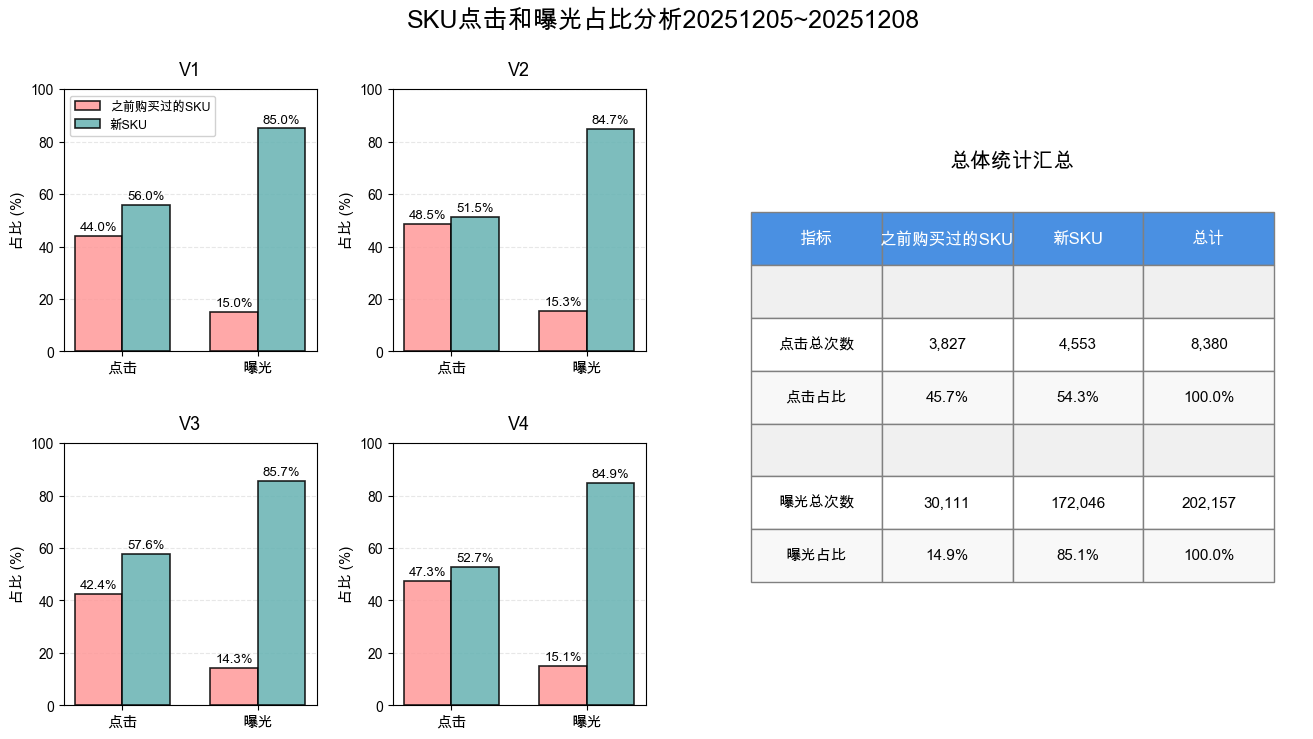


总体统计:
------------------------------------------------------------------------------------------
   是否新sku  sku点击总次数  sku曝光总次数  点击占比(%)  曝光占比(%)
之前购买过的SKU      3827     30111     45.7     14.9
     新SKU      4553    172046     54.3     85.1


In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = result_df

# Calculate shares within each variant_list
result = df.groupby('variant_list').apply(
    lambda x: pd.DataFrame({
        '是否新sku': x['是否新sku'],
        'sku点击总次数': x['sku点击总次数'],
        'sku点击占比(%)': (x['sku点击总次数'] / x['sku点击总次数'].sum() * 100).round(2),
        'sku曝光总次数': x['sku曝光总次数'],
        'sku曝光占比(%)': (x['sku曝光总次数'] / x['sku曝光总次数'].sum() * 100).round(2)
    })
).reset_index(drop=True)

result.insert(0, 'variant_list', df['variant_list'])

print("=" * 90)
print("SKU点击和曝光占比分析 (按variant_list分组)")
print("=" * 90)
print(result.to_string(index=False))
print("=" * 90)

# Redesigned compact visualization
fig = plt.figure(figsize=(16, 8))
gs = fig.add_gridspec(2, 4, hspace=0.35, wspace=0.3)

fig.suptitle(f'SKU点击和曝光占比分析{date_range}', fontsize=18, fontweight='bold', y=0.98)

variants = df['variant_list'].unique()
colors_old = '#FF9999'
colors_new = '#66B2B2'

for idx, variant in enumerate(variants):
    variant_data = result[result['variant_list'] == variant].reset_index(drop=True)
    
    # Create subplot
    ax = fig.add_subplot(gs[idx // 2, idx % 2])
    
    # Prepare data
    categories = ['点击', '曝光']
    old_sku_values = [variant_data.loc[0, 'sku点击占比(%)'], 
                      variant_data.loc[0, 'sku曝光占比(%)']]
    new_sku_values = [variant_data.loc[1, 'sku点击占比(%)'], 
                      variant_data.loc[1, 'sku曝光占比(%)']]
    
    x = np.arange(len(categories))
    width = 0.35
    
    # Create grouped bars
    bars1 = ax.bar(x - width/2, old_sku_values, width, label='之前购买过的SKU',
                   color=colors_old, alpha=0.85, edgecolor='black', linewidth=1.2)
    bars2 = ax.bar(x + width/2, new_sku_values, width, label='新SKU',
                   color=colors_new, alpha=0.85, edgecolor='black', linewidth=1.2)
    
    # Customize
    ax.set_ylabel('占比 (%)', fontsize=11, fontweight='bold')
    ax.set_title(f'{variant}', fontsize=13, fontweight='bold', pad=10)
    ax.set_xticks(x)
    ax.set_xticklabels(categories, fontsize=11)
    ax.set_ylim(0, 100)
    ax.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.8)
    ax.set_axisbelow(True)
    
    # Add value labels on bars
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height + 1,
                    f'{height:.1f}%',
                    ha='center', va='bottom', fontsize=9.5, fontweight='bold')
    
    # Add legend only to first subplot
    if idx == 0:
        ax.legend(loc='upper left', fontsize=9, framealpha=0.9)

# Add summary table on the right
ax_table = fig.add_subplot(gs[:, 2:])
ax_table.axis('off')

# Calculate summary
summary = df.groupby('是否新sku').agg({
    'sku点击总次数': 'sum',
    'sku曝光总次数': 'sum'
}).reset_index()
summary['点击占比(%)'] = (summary['sku点击总次数'] / summary['sku点击总次数'].sum() * 100).round(1)
summary['曝光占比(%)'] = (summary['sku曝光总次数'] / summary['sku曝光总次数'].sum() * 100).round(1)

# Create detailed table data
table_data = []
table_data.append(['指标', '之前购买过的SKU', '新SKU', '总计'])
table_data.append(['', '', '', ''])

# Clicks
old_clicks = summary.loc[0, 'sku点击总次数']
new_clicks = summary.loc[1, 'sku点击总次数']
total_clicks = old_clicks + new_clicks
table_data.append(['点击总次数', f'{old_clicks:,}', f'{new_clicks:,}', f'{total_clicks:,}'])
table_data.append(['点击占比', 
                   f"{summary.loc[0, '点击占比(%)']:.1f}%",
                   f"{summary.loc[1, '点击占比(%)']:.1f}%",
                   '100.0%'])
table_data.append(['', '', '', ''])

# Impressions
old_imps = summary.loc[0, 'sku曝光总次数']
new_imps = summary.loc[1, 'sku曝光总次数']
total_imps = old_imps + new_imps
table_data.append(['曝光总次数', f'{old_imps:,}', f'{new_imps:,}', f'{total_imps:,}'])
table_data.append(['曝光占比', 
                   f"{summary.loc[0, '曝光占比(%)']:.1f}%",
                   f"{summary.loc[1, '曝光占比(%)']:.1f}%",
                   '100.0%'])

# Create table
table = ax_table.table(cellText=table_data, cellLoc='center', loc='center',
                       bbox=[0.05, 0.2, 0.9, 0.6])
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 2.2)

# Style table
for i in range(len(table_data)):
    for j in range(4):
        cell = table[(i, j)]
        if i == 0:  # Header row
            cell.set_facecolor('#4A90E2')
            cell.set_text_props(weight='bold', color='white', fontsize=12)
        elif i in [1, 4]:  # Empty rows
            cell.set_facecolor('#F0F0F0')
        elif i in [2, 5]:  # Data rows
            cell.set_facecolor('#FFFFFF')
        else:  # Percentage rows
            cell.set_facecolor('#F8F8F8')
        cell.set_edgecolor('gray')
        cell.set_linewidth(1)

ax_table.text(0.5, 0.9, '总体统计汇总', ha='center', va='top',
              fontsize=15, fontweight='bold', transform=ax_table.transAxes)

plt.show()

# Print summary
print("\n总体统计:")
print("-" * 90)
print(summary.to_string(index=False))